In [1]:
from sklearn.tree import  DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
phase1DF = pd.read_csv(r'FinalData\phase1.csv')
phase2DF = pd.read_csv(r'FinalData\phase2.csv')
phase3DF = pd.read_csv(r'FinalData\phase3.csv')
preOpDataDF = pd.read_csv(r'FinalData\PreOp.csv')
outComesDF = pd.read_csv(r'FinalData\OutComes.csv')

phase1DF.columns = [phase1DF.columns[0]] + ['P1_' + col for col in phase1DF.columns[1:]]
phase2DF.columns = [phase2DF.columns[0]] + ['P2_' + col for col in phase2DF.columns[1:]]
phase3DF.columns = [phase3DF.columns[0]] + ['P3_' + col for col in phase3DF.columns[1:-9]] + list(phase3DF.columns[-9:])

preOpData = preOpDataDF
phase1Data = pd.merge(preOpData, phase1DF , on = 'CPR' , how = 'left')
phase2Data = pd.merge(phase1Data, phase2DF , on = 'CPR' , how = 'left')
phase3Data = pd.merge(phase2Data, phase3DF , on = 'CPR' , how = 'left')

""" allData = pd.merge(preOpDataDF, phase1DF , on = 'CPR' , how = 'left')
allData = pd.merge(allData, phase2DF , on = 'CPR' , how = 'left')
allData = pd.merge(allData, phase3DF , on = 'CPR' , how = 'left')
allData = allData.drop(columns = [])
allData """

" allData = pd.merge(preOpDataDF, phase1DF , on = 'CPR' , how = 'left')\nallData = pd.merge(allData, phase2DF , on = 'CPR' , how = 'left')\nallData = pd.merge(allData, phase3DF , on = 'CPR' , how = 'left')\nallData = allData.drop(columns = [])\nallData "

In [3]:
outComesDF['within90Days'].value_counts()

within90Days
0    3761
1     128
Name: count, dtype: int64

In [4]:
data0 = preOpData.copy()
data1 = phase1Data.copy()
data2 = phase2Data.copy()
data3 = phase3Data.copy()


# Categorising the one-hot encoded data


categoricalData = pd.DataFrame(data0['CPR'])


# """ OperationOrder = ['FC', 'FE', 'FG', 'FK', 'FM', 'FN', 'FP', 'FW', 'FX']
# categoricalData['Operations'] = data[OperationOrder].apply(lambda row: int("".join(map(str, row)), 2), axis=1) """



smokingOrder = ['SmokingStatus_No', 'SmokingStatus_Not anymore', 'SmokingStatus_Not asked', 'SmokingStatus_Yes']
categoricalData['Smoking'] = data0[smokingOrder].idxmax(axis=1).apply(lambda x: smokingOrder.index(x)).to_numpy()
alcoholOrder = ['AlcoholPerWeek_0','AlcoholPerWeek_0.5-10', 'AlcoholPerWeek_11-20', 'AlcoholPerWeek_21-30', 'AlcoholPerWeek_31+']
categoricalData['Alcohol'] = data0[alcoholOrder].idxmax(axis=1).apply(lambda x: alcoholOrder.index(x)).to_numpy()



#""" diagnosesOrder = ['DiagnosisName_AcuteKidneyFailure', 'DiagnosisName_Arteriosclerosis', 'DiagnosisName_ChronicCAD', 
#                  'DiagnosisName_ChronicKidneyFailure', 'DiagnosisName_EssentialHypertension', 'DiagnosisName_HyperChol', 
#                  'DiagnosisName_Overweight', 'DiagnosisName_T1Diabetes', 'DiagnosisName_T2Diabetes']
#categoricalData['Diagnoses'] = data[diagnosesOrder].apply(lambda row: int("".join(map(str, row)), 2), axis=1) """

preOpData = data0.drop(columns = ['SmokingStatus_No', 'SmokingStatus_Not anymore', 'SmokingStatus_Not asked', 'SmokingStatus_Yes', 
                            'AlcoholPerWeek_0','AlcoholPerWeek_0.5-10', 'AlcoholPerWeek_11-20', 'AlcoholPerWeek_21-30', 'AlcoholPerWeek_31+',
                            ])
phase1Data = data1.drop(columns = ['SmokingStatus_No', 'SmokingStatus_Not anymore', 'SmokingStatus_Not asked', 'SmokingStatus_Yes', 
                            'AlcoholPerWeek_0','AlcoholPerWeek_0.5-10', 'AlcoholPerWeek_11-20', 'AlcoholPerWeek_21-30', 'AlcoholPerWeek_31+',
                            ])
phase2Data = data2.drop(columns = ['SmokingStatus_No', 'SmokingStatus_Not anymore', 'SmokingStatus_Not asked', 'SmokingStatus_Yes',
                            'AlcoholPerWeek_0','AlcoholPerWeek_0.5-10', 'AlcoholPerWeek_11-20', 'AlcoholPerWeek_21-30', 'AlcoholPerWeek_31+',
                            ])
phase3Data = data3.drop(columns = ['SmokingStatus_No', 'SmokingStatus_Not anymore', 'SmokingStatus_Not asked', 'SmokingStatus_Yes',
                            'AlcoholPerWeek_0','AlcoholPerWeek_0.5-10', 'AlcoholPerWeek_11-20', 'AlcoholPerWeek_21-30', 'AlcoholPerWeek_31+',
                            ])

preOpData  = pd.merge(preOpData, categoricalData , on = 'CPR' , how = 'left')
phase1Data = pd.merge(phase1Data, categoricalData , on = 'CPR' , how = 'left')
phase2Data = pd.merge(phase2Data, categoricalData , on = 'CPR' , how = 'left')
phase3Data = pd.merge(phase3Data, categoricalData , on = 'CPR' , how = 'left')

preOpData  = preOpData.drop(columns = 'CPR')
phase1Data = phase1Data.drop(columns = 'CPR')
phase2Data = phase2Data.drop(columns = 'CPR')
phase3Data = phase3Data.drop(columns = 'CPR')

#X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(normData, outComesDF, test_size=0.2, stratify=outComesDF['within90Days'], random_state=0)


Define Folds, features and outcomes

In [5]:
# Define folds using StratifiedKFold
outerFolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
innerFolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


# Define the dataset and target variable for the first phase
Xpre = preOpData
Xphase1 = phase1Data
Xphase2 = phase2Data
Xphase3 = phase3Data
y = outComesDF['within90Days']



In [6]:
def trainModel(model, paramGrid, X, phase, type) :
    outerPR = []
    outerROC = []
    outerPRAUC = []
    mean_recall = np.linspace(0, 1, 100)
    precisions = []
    pr_aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    colors = sns.color_palette("colorblind", n_colors=5)

    plt.figure(figsize=(16, 6))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    rocAx = axes[0]
    prAx = axes[1]
    foldCount = 1

    for train, test in outerFolds.split(X,y) :
        
        Xtrain, Xtest = X.iloc[train], X.iloc[test]
        yTrain, yTest = y.iloc[train], y.iloc[test]

        gridSearch = GridSearchCV(model, paramGrid, cv=innerFolds, 
                                            verbose=4, 
                                            scoring='roc_auc', 
                                            return_train_score=True, 
                                            n_jobs=-1)
        gridSearch.fit(Xtrain, yTrain)

        bestModel = gridSearch.best_estimator_

        results = gridSearch.cv_results_
        bestModel = gridSearch.best_estimator_
        bestParams = gridSearch.best_params_

        # Evaluate the model on the holdout set
        yScores = bestModel.predict_proba(Xtest)[:,1]

        fpr, tpr, _ = roc_curve(yTest, yScores)
        rocAuc = auc(fpr, tpr)
        
        aucs.append(rocAuc)

        # Interpolate to the common mean_fpr grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        
        rocAx.plot(fpr, tpr, lw=2, color=colors[foldCount - 1], label=f'ROC Fold {foldCount} (area = {rocAuc:.2f})')

        precision, recall, _ = precision_recall_curve(yTest, yScores)
        prAuc = auc(recall, precision)
        pr_aucs.append(prAuc)

        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])  # reverse needed due to decreasing recall
        precisions.append(interp_precision)

        prAx.plot(recall, precision, lw=2, color=colors[foldCount - 1], label=f'PR Fold {foldCount} (area = {prAuc:.2f})')

        foldCount+=1

        # Calculate metrics
        holdoutPR = prAuc * 100
        holdoutAUC = roc_auc_score(yTest, yScores) * 100  # Use probabilities for AUC

        outerPR.append(holdoutPR)
        outerROC.append(holdoutAUC)

        # Print the summary
        print(f"Best parameters: {bestParams}")
        print(f"Holdout Set PR AUC: {holdoutPR:.2f}%")
        print(f"Holdout Set ROC AUC: {holdoutAUC:.2f}%")


    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)    
    rocAx.plot(mean_fpr, mean_tpr, color='navy', linestyle='-', linewidth=3,
               label=f'Mean ROC (area = {mean_auc:.2f})')
    rocAx.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                       color='navy', alpha=0.2, label=r'$\pm$ 1 std. dev.')   
    rocAx.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    rocAx.set_xlim([0.0, 1.0])
    rocAx.set_ylim([0.0, 1.05])
    rocAx.set_xlabel('False Positive Rate')
    rocAx.set_ylabel('True Positive Rate')
    rocAx.set_title('Receiver Operating Characteristic (ROC) of ' + type + ' in phase %d' % phase)
    rocAx.legend(loc="lower right", fontsize='large')
    rocAx.grid(alpha=0.3)

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)

    prAx.plot(mean_recall, mean_precision, color='darkorange', linestyle='-', linewidth=3,
              label=f'Mean PR (area = {mean_pr_auc:.2f})')
    prAx.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision,
                      color='orange', alpha=0.2, label=r'$\pm$ 1 std. dev.')
    prAx.set_xlim([0.0, 1.0])
    prAx.set_ylim([0.0, 1.05])
    prAx.set_xlabel('Recall')
    prAx.set_ylabel('Precision')
    prAx.set_title('Precision-Recall (PR) Curve of ' + type + ' in phase %d' % phase)
    prAx.legend(loc="upper right", fontsize='large')
    prAx.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return outerPR, outerROC



### Regression

In [7]:
C_parameter = np.logspace(-5, 5, 20)
model = LogisticRegression()


paramGrid = {
    'penalty' : ['l2'],
    'C' : C_parameter,
    'solver' : ['lbfgs'],
    'max_iter' : [10000],
    'class_weight'  : [None]
    }



#### Regression - PreOp

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.1623776739188721), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 15.13%
Holdout Set ROC AUC: 77.91%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.04832930238571752), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 18.21%
Holdout Set ROC AUC: 78.92%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.04832930238571752), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 10.35%
Holdout Set ROC AUC: 72.86%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.04832930238571752), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 25.15%
Holdout Set ROC AUC: 81.40%
F

<Figure size 1600x600 with 0 Axes>

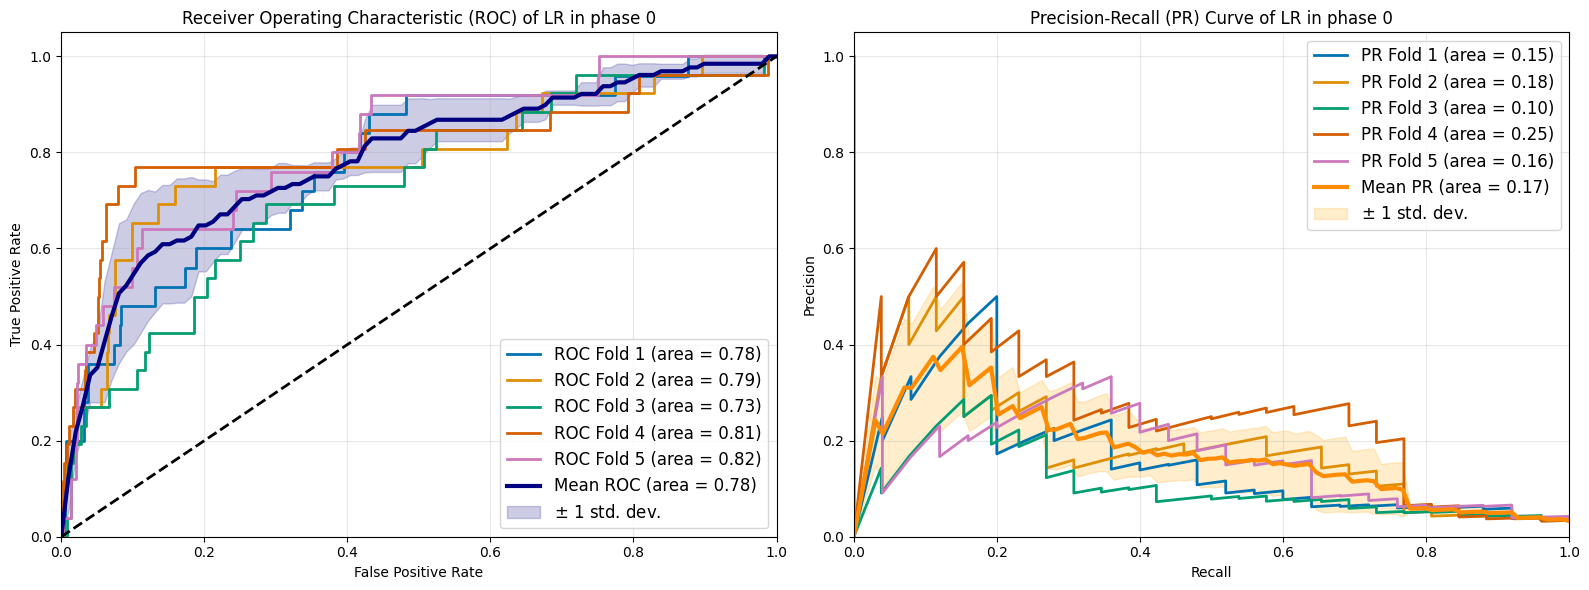

In [8]:
outerPR, outerROC = trainModel(model, paramGrid, Xpre , phase=0, type='LR')

In [9]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 16.9502 
 standard deviation: 4.8330 
 standard error of mean: 2.1614
Nested CV ROC: 
 mean: 78.5213 
 standard deviation: 3.1571 
 standard error of mean: 1.4119


#### Regression - Phase 1

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.1623776739188721), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 15.81%
Holdout Set ROC AUC: 79.24%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.01438449888287663), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 14.30%
Holdout Set ROC AUC: 76.38%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.01438449888287663), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 10.55%
Holdout Set ROC AUC: 72.73%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.01438449888287663), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 20.43%
Holdout Set ROC AUC: 77.32%
F

<Figure size 1600x600 with 0 Axes>

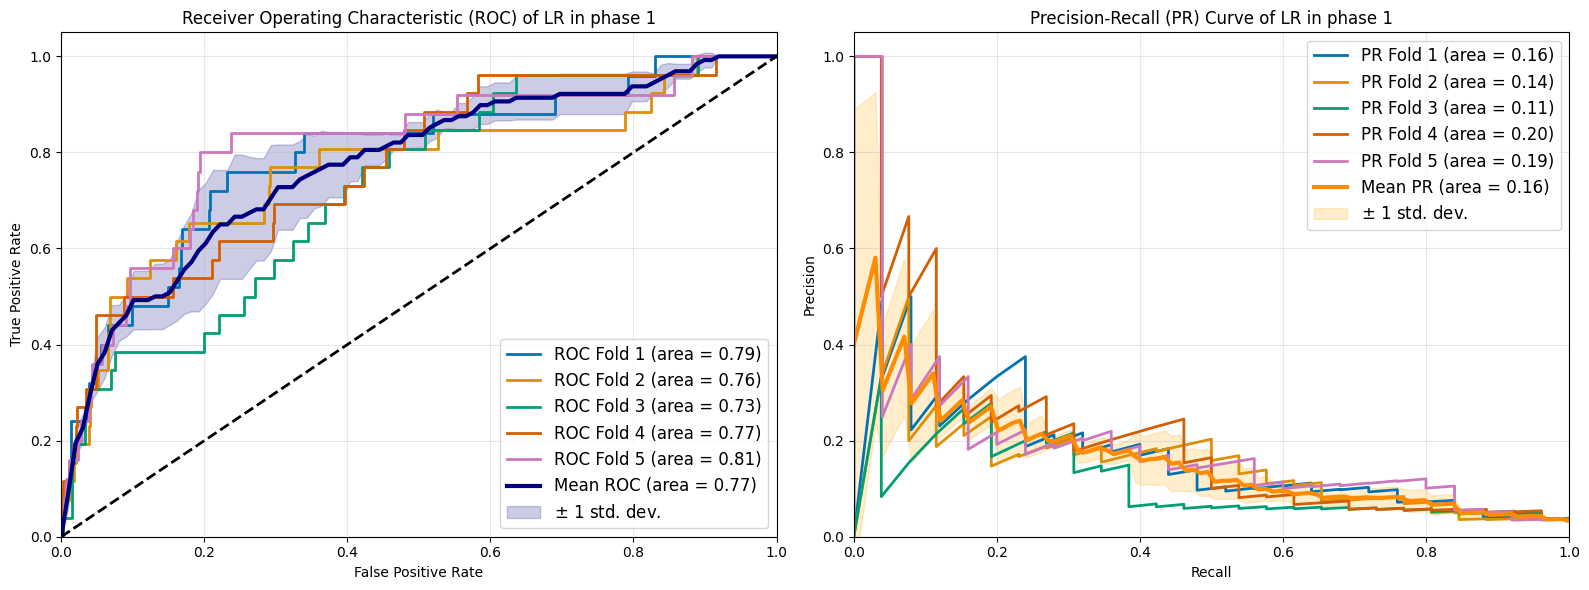

In [10]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase1 , phase=1, type='LR')

In [11]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 15.9698 
 standard deviation: 3.4588 
 standard error of mean: 1.5468
Nested CV ROC: 
 mean: 77.3654 
 standard deviation: 2.8425 
 standard error of mean: 1.2712


#### Regression - Phase 2

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.01438449888287663), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 25.68%
Holdout Set ROC AUC: 85.55%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.004281332398719391), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 15.97%
Holdout Set ROC AUC: 72.10%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.1623776739188721), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 14.07%
Holdout Set ROC AUC: 68.90%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.004281332398719391), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 18.90%
Holdout Set ROC AUC: 74.24%

<Figure size 1600x600 with 0 Axes>

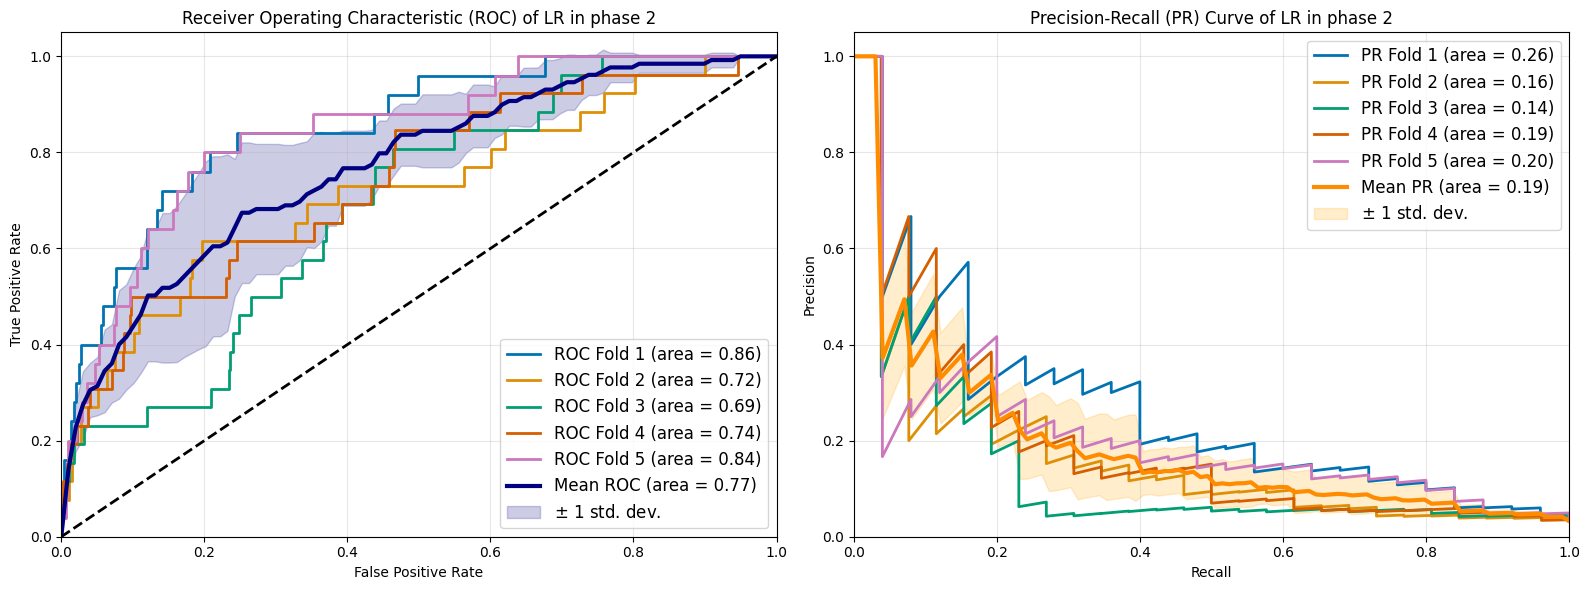

In [12]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase2 , phase=2, type='LR')

In [13]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 18.9696 
 standard deviation: 3.9928 
 standard error of mean: 1.7856
Nested CV ROC: 
 mean: 77.0266 
 standard deviation: 6.6986 
 standard error of mean: 2.9957


#### Regression - Phase 3

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.004281332398719391), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 20.83%
Holdout Set ROC AUC: 84.50%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.004281332398719391), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 26.23%
Holdout Set ROC AUC: 76.32%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(3.359818286283781e-05), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 10.00%
Holdout Set ROC AUC: 68.58%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(0.00011288378916846884), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 26.12%
Holdout Set ROC AUC: 

<Figure size 1600x600 with 0 Axes>

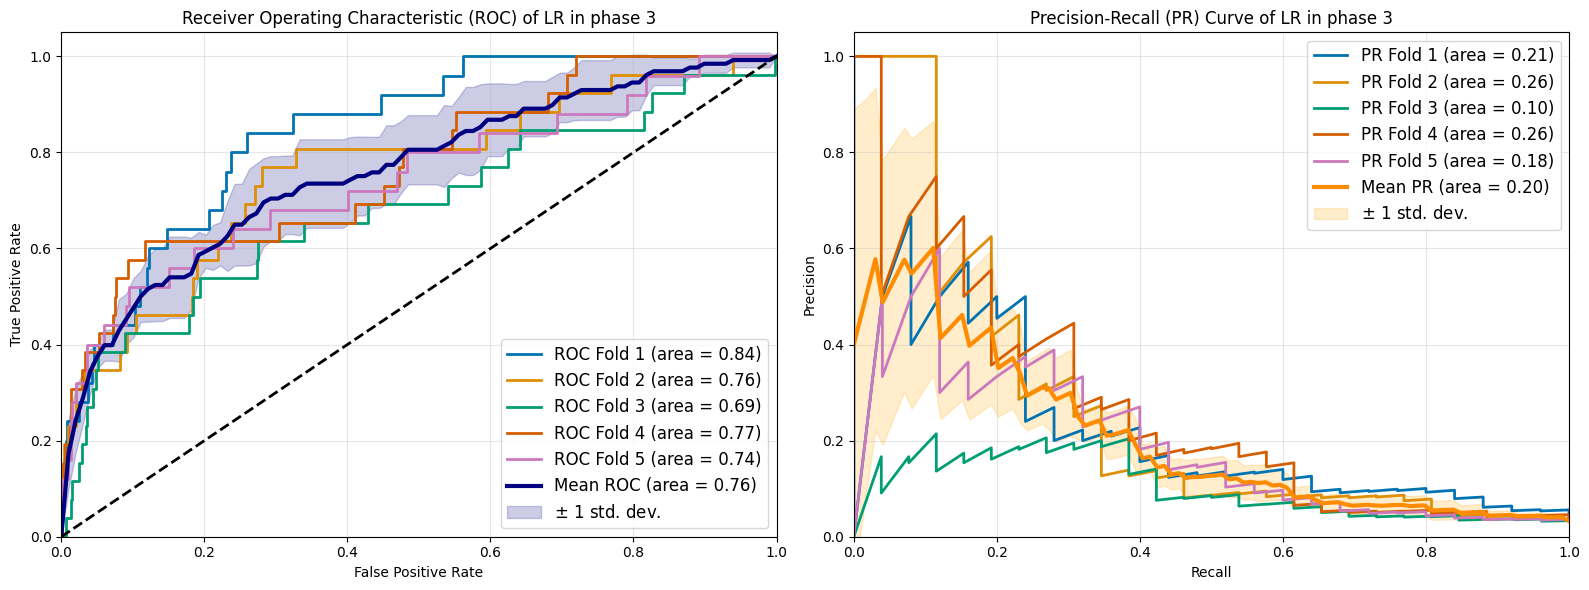

In [14]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase3 , phase=3, type='LR')

In [15]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 20.3027 
 standard deviation: 5.9867 
 standard error of mean: 2.6774
Nested CV ROC: 
 mean: 76.2090 
 standard deviation: 5.1217 
 standard error of mean: 2.2905


### Tree

In [16]:
model = DecisionTreeClassifier(random_state=0)

paramGrid = {
    'criterion': ['entropy'],
    'max_depth': [None, 5, 10, 15, 20],              
    'max_features': [None],  #None
    'class_weight': [None],   #None
}

#### Tree - preOp

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 13.24%
Holdout Set ROC AUC: 69.57%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 5.58%
Holdout Set ROC AUC: 59.69%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 5.13%
Holdout Set ROC AUC: 55.01%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 6.22%
Holdout Set ROC AUC: 63.02%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth'

<Figure size 1600x600 with 0 Axes>

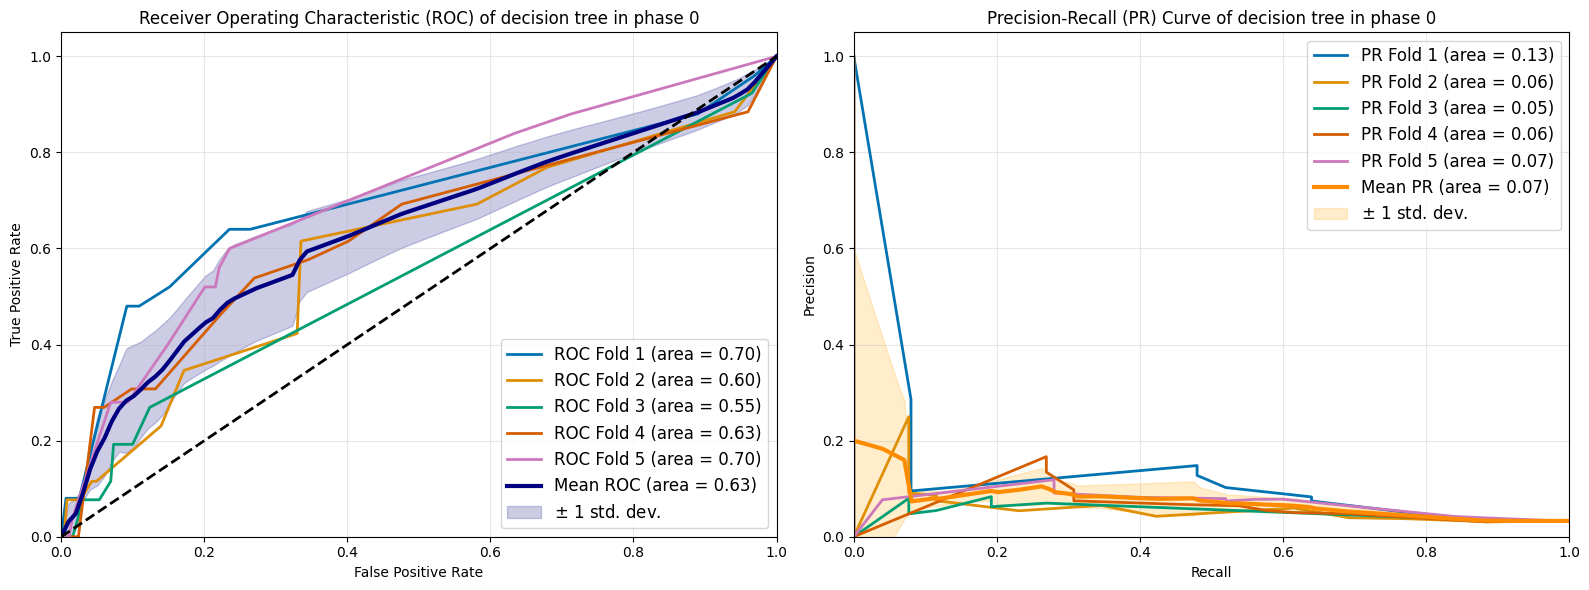

In [17]:
outerPR, outerROC = trainModel(model, paramGrid, Xpre , phase=0, type='decision tree')

In [18]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 7.4665 
 standard deviation: 2.9655 
 standard error of mean: 1.3262
Nested CV ROC: 
 mean: 63.4959 
 standard deviation: 5.8016 
 standard error of mean: 2.5945


#### Tree - phase 1

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 9.44%
Holdout Set ROC AUC: 65.51%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 6.83%
Holdout Set ROC AUC: 68.13%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 5.43%
Holdout Set ROC AUC: 64.59%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 5.09%
Holdout Set ROC AUC: 54.28%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth':

<Figure size 1600x600 with 0 Axes>

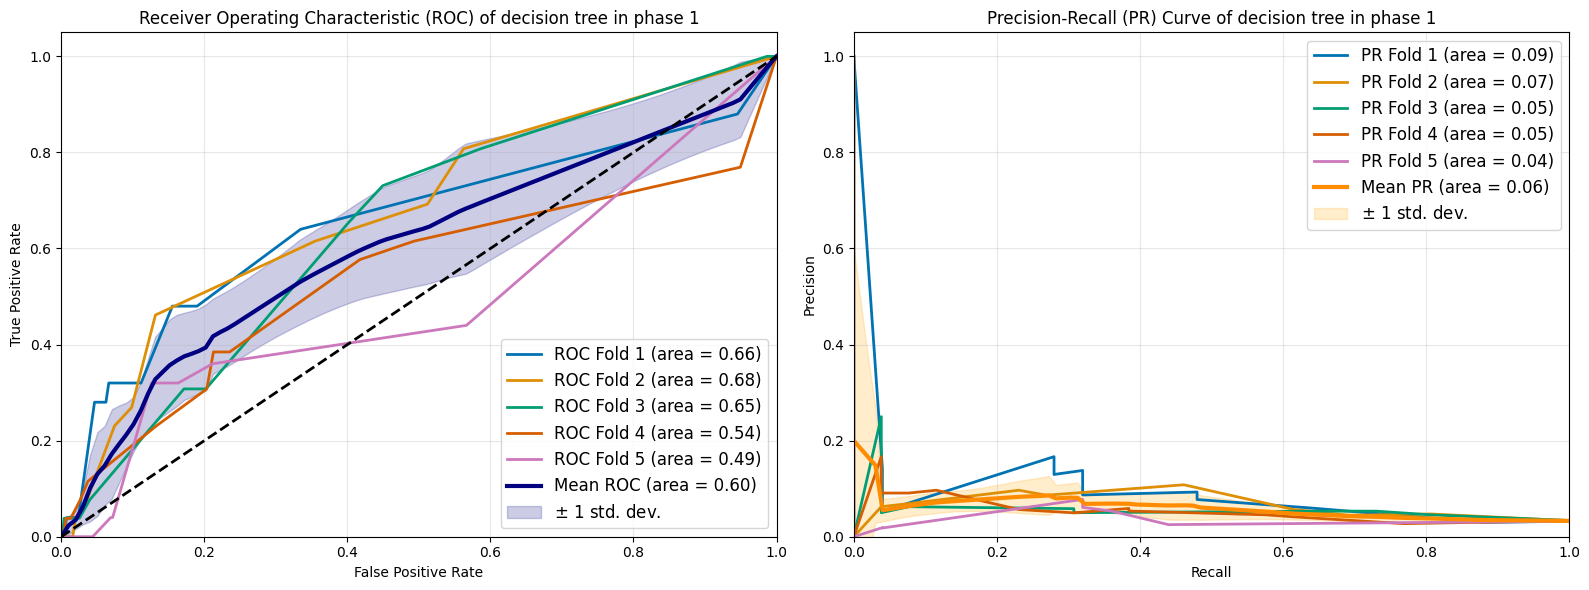

In [19]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase1 , phase=1, type='decision tree')

In [20]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 6.0644 
 standard deviation: 1.9873 
 standard error of mean: 0.8888
Nested CV ROC: 
 mean: 60.3589 
 standard deviation: 7.2745 
 standard error of mean: 3.2532


#### Tree - phase 2

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 6.76%
Holdout Set ROC AUC: 65.10%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 7.88%
Holdout Set ROC AUC: 68.74%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None}
Holdout Set PR AUC: 18.63%
Holdout Set ROC AUC: 56.56%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 8.55%
Holdout Set ROC AUC: 59.56%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_dep

<Figure size 1600x600 with 0 Axes>

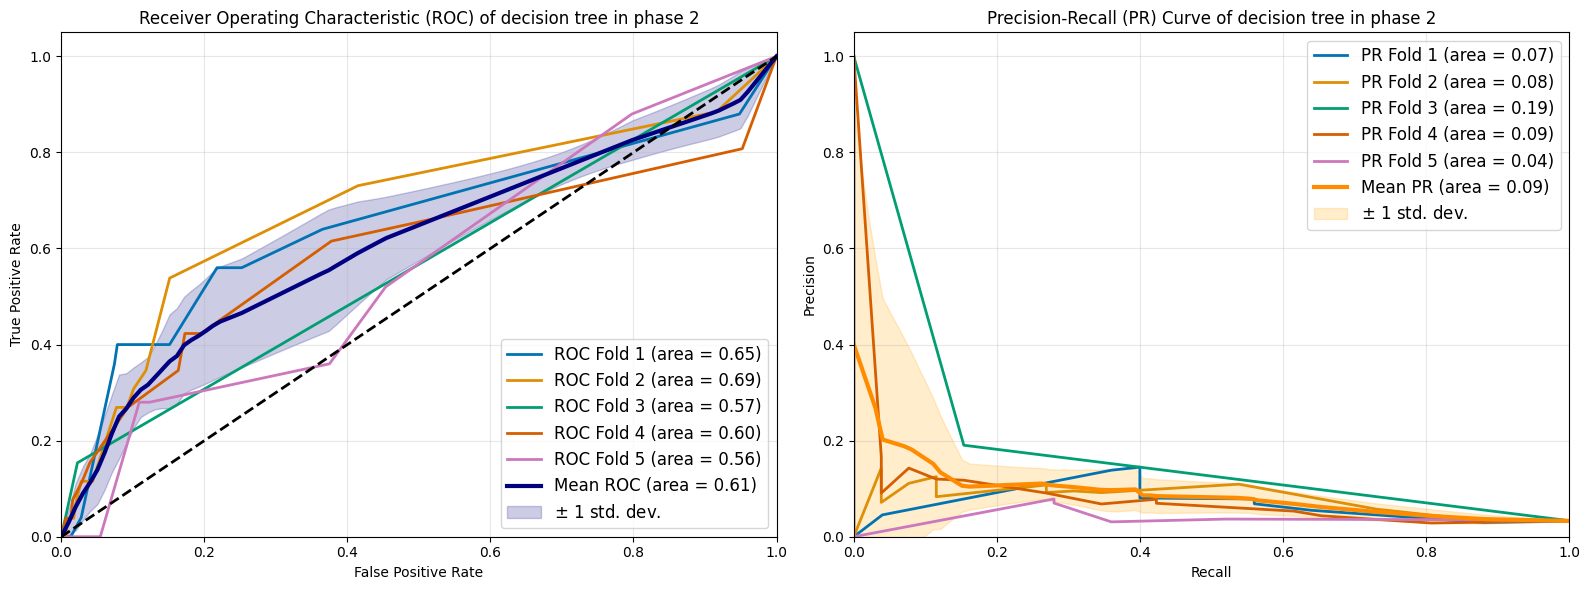

In [21]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase2 , phase=2, type='decision tree')

In [22]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 9.1134 
 standard deviation: 5.0344 
 standard error of mean: 2.2515
Nested CV ROC: 
 mean: 61.1490 
 standard deviation: 5.0142 
 standard error of mean: 2.2424


#### Tree - phase 3

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 19.09%
Holdout Set ROC AUC: 72.48%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 16.81%
Holdout Set ROC AUC: 59.74%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 15.70%
Holdout Set ROC AUC: 73.23%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 12.78%
Holdout Set ROC AUC: 62.09%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_dep

<Figure size 1600x600 with 0 Axes>

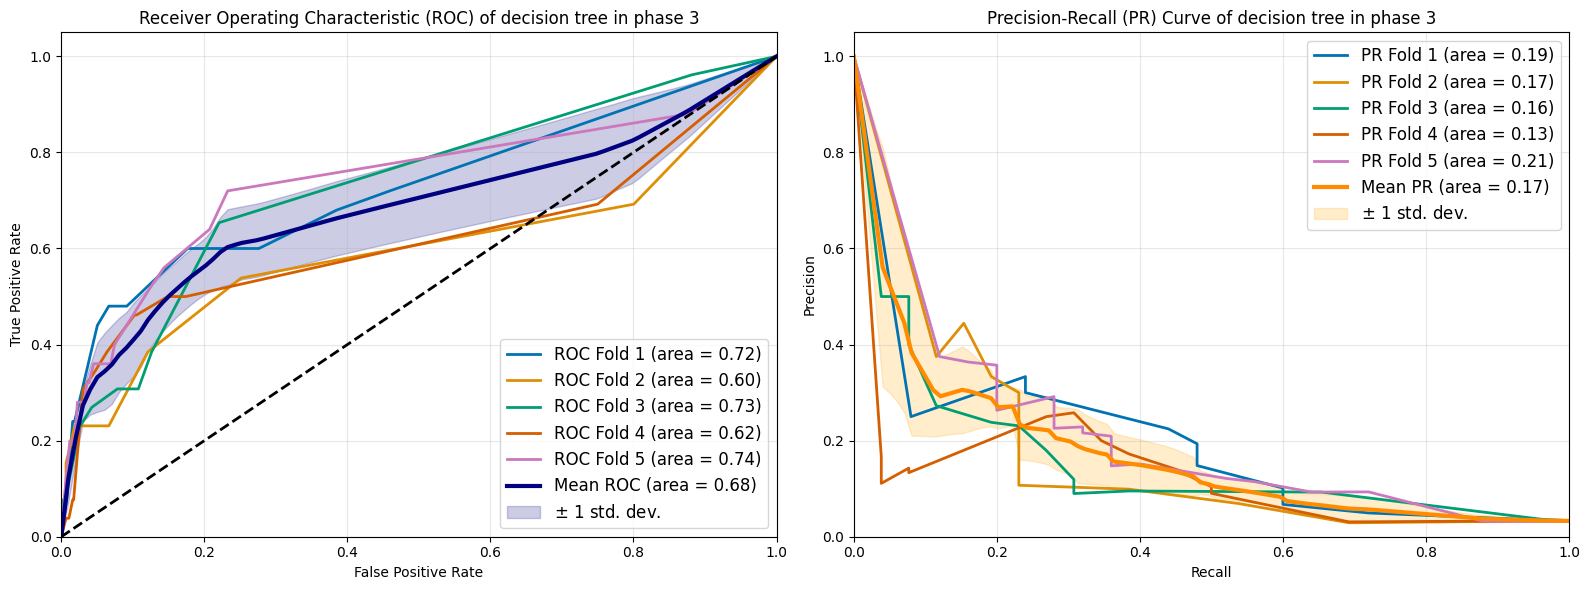

In [23]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase3 , phase=3, type='decision tree')

In [24]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 17.0414 
 standard deviation: 2.7744 
 standard error of mean: 1.2407
Nested CV ROC: 
 mean: 68.3261 
 standard deviation: 6.1207 
 standard error of mean: 2.7373


In [25]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_tree_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_tree_death.fit(Xtrain, yTrain)

    bestModel = grid_search_tree_death.best_estimator_



    results_tree_death = grid_search_tree_death.cv_results_
    best_model_tree_death = grid_search_tree_death.best_estimator_
    best_params_tree_death = grid_search_tree_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_tree_death = best_model_tree_death.predict_proba(Xtest)[:,1]

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(yTest, y_pred_tree_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_tree_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    # Calculate metrics
    holdout_pr_tree_death = pr_auc * 100
    holdout_auc_tree_death = roc_auc_score(yTest, y_pred_tree_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_tree_death)
    outerROC.append(holdout_auc_tree_death)

    # Print the summary
    print(f"Best parameters: {best_params_tree_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_tree_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_tree_death:.2f}%")

    


    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_tree_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_tree_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_tree_death.best_estimator_\n\n\n\n    results_tree_death = grid_search_tree_death.cv_results_\n    best_model_tree_death = grid_search_tree_death.best_estimator_\n    best_params_tree_death = grid_search_tree_death.best_params_\n\n    # Evaluate the model on the holdout set\

### ANN

In [26]:
model = MLPClassifier(max_iter=1000, random_state=0) #Increase max_iter
C_parameter = np.logspace(-5, 5, 10)
paramGrid = {
    'hidden_layer_sizes': [(2,), (5,), (10,), (2, 2,), (5,5,), (10,), (10,10,)], #potentially not 15 20
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': C_parameter, 
    'learning_rate_init': [0.001, 0.01, 0.1] 
}


#### ANN - PreOp

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (5, 5), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 7.08%
Holdout Set ROC AUC: 71.19%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0016681005372000592), 'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.1, 'solver': 'adam'}
Holdout Set PR AUC: 15.66%
Holdout Set ROC AUC: 78.81%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.021544346900318846), 'hidden_layer_sizes': (5, 5), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 6.21%
Holdout Set ROC AUC: 69.82%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0016681005372000592), 'hidden_layer_sizes': (2, 2), 'le

<Figure size 1600x600 with 0 Axes>

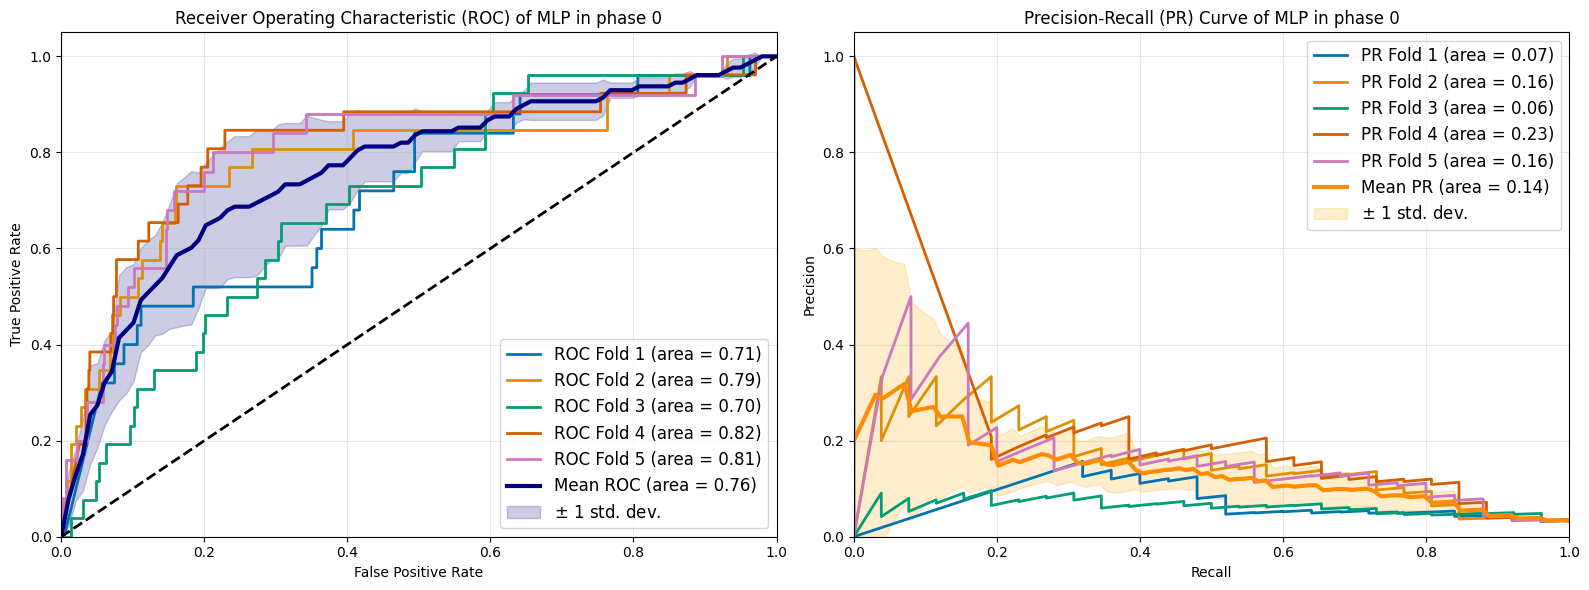

In [27]:
outerPR, outerROC = trainModel(model, paramGrid, Xpre , phase=0, type='MLP')

In [28]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 13.6609 
 standard deviation: 6.3676 
 standard error of mean: 2.8477
Nested CV ROC: 
 mean: 76.4851 
 standard deviation: 4.9845 
 standard error of mean: 2.2292


#### ANN - phase 1

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (2,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 29.77%
Holdout Set ROC AUC: 78.77%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.021544346900318846), 'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.001, 'solver': 'adam'}
Holdout Set PR AUC: 9.45%
Holdout Set ROC AUC: 78.74%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0016681005372000592), 'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 8.24%
Holdout Set ROC AUC: 71.90%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (5, 5), 'learning_rate_init':

<Figure size 1600x600 with 0 Axes>

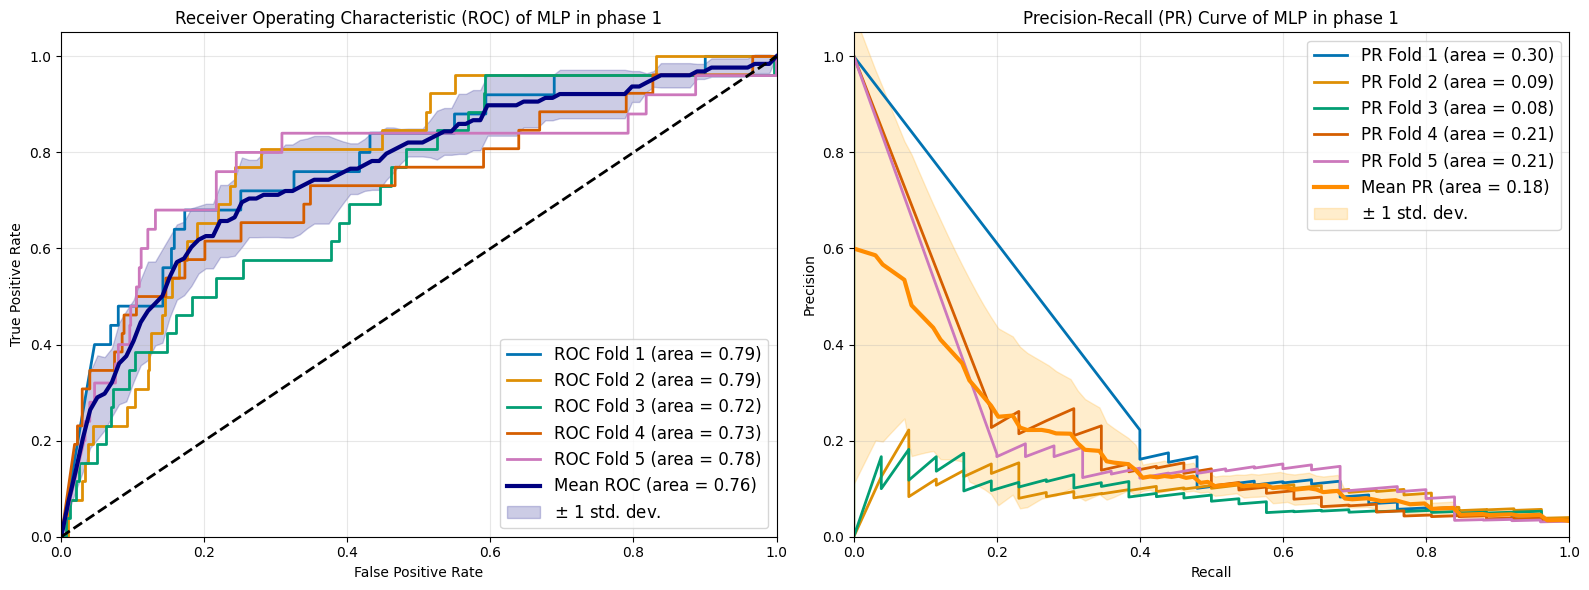

In [29]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase1 , phase=1, type='MLP')

In [30]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 17.8841 
 standard deviation: 8.0596 
 standard error of mean: 3.6044
Nested CV ROC: 
 mean: 76.0637 
 standard deviation: 2.8768 
 standard error of mean: 1.2866


#### ANN - phase 2

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0001291549665014884), 'hidden_layer_sizes': (5, 5), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 31.97%
Holdout Set ROC AUC: 82.39%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 12.10%
Holdout Set ROC AUC: 77.37%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.1, 'solver': 'adam'}
Holdout Set PR AUC: 17.31%
Holdout Set ROC AUC: 69.04%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.1, 'solver

<Figure size 1600x600 with 0 Axes>

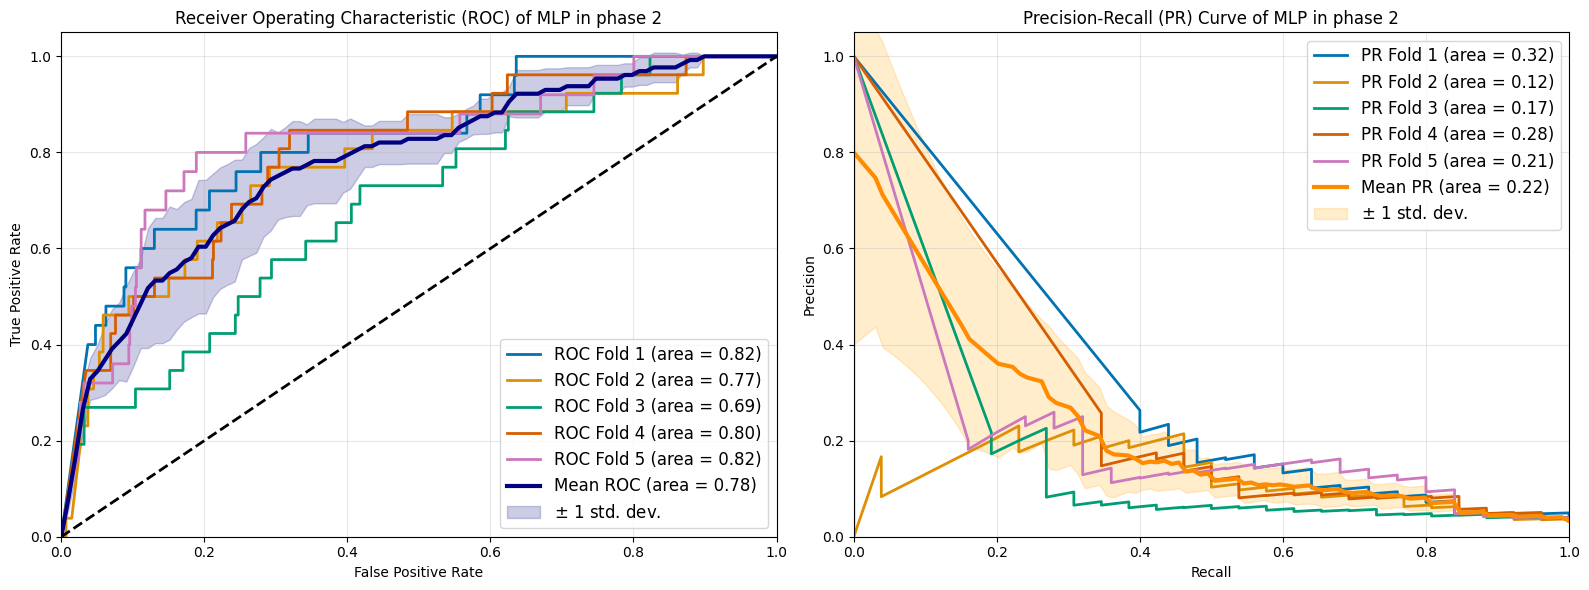

In [31]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase2 , phase=2, type='MLP')

In [32]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 22.0588 
 standard deviation: 7.1654 
 standard error of mean: 3.2045
Nested CV ROC: 
 mean: 78.0347 
 standard deviation: 4.8203 
 standard error of mean: 2.1557


#### ANN - phase 3

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0001291549665014884), 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 26.44%
Holdout Set ROC AUC: 83.50%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.0001291549665014884), 'hidden_layer_sizes': (5, 5), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 24.67%
Holdout Set ROC AUC: 79.16%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(1e-05), 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Holdout Set PR AUC: 13.62%
Holdout Set ROC AUC: 70.26%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(0.2782559402207126), 'hidden_layer_sizes': (5, 5), 'learn

<Figure size 1600x600 with 0 Axes>

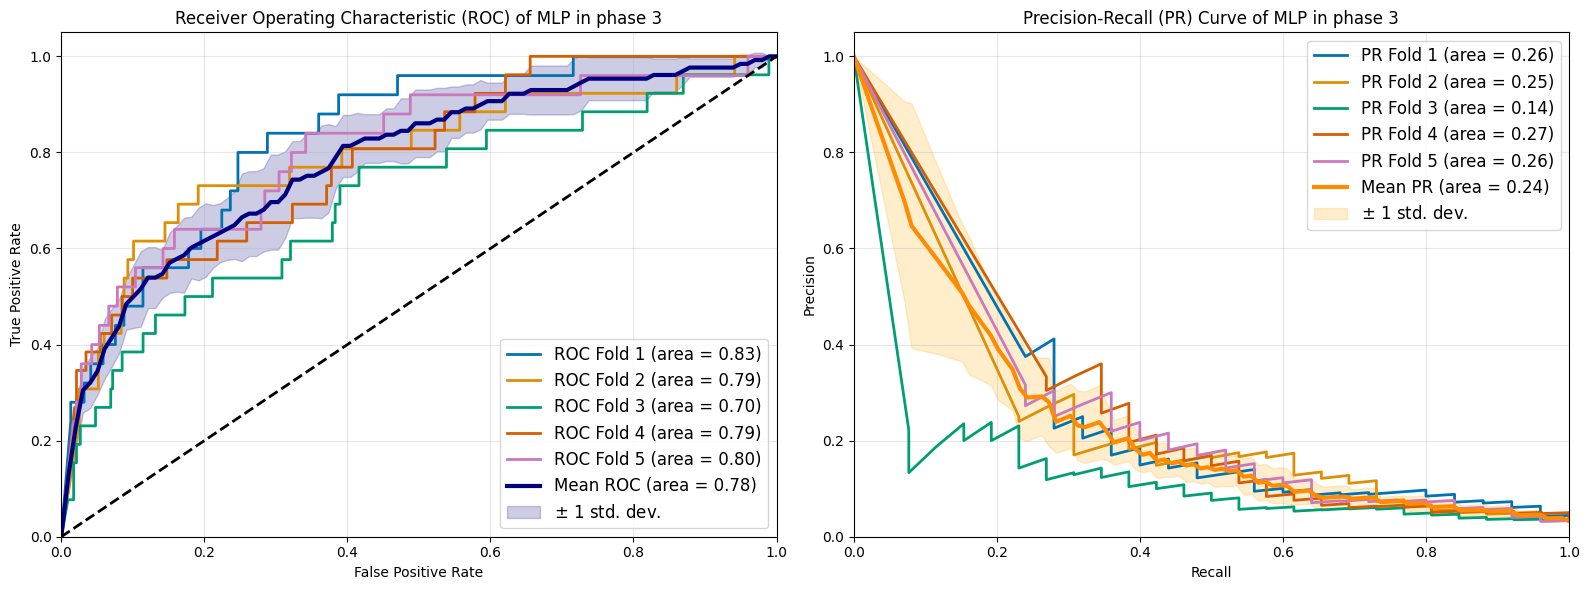

In [33]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase3 , phase=3, type='MLP')

In [34]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 23.6221 
 standard deviation: 5.0729 
 standard error of mean: 2.2687
Nested CV ROC: 
 mean: 78.4316 
 standard deviation: 4.3968 
 standard error of mean: 1.9663


In [35]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_mlp_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_mlp_death.fit(Xtrain, yTrain)

    bestModel = grid_search_mlp_death.best_estimator_



    results_mlp_death = grid_search_mlp_death.cv_results_
    best_model_mlp_death = grid_search_mlp_death.best_estimator_
    best_params_mlp_death = grid_search_mlp_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_mlp_death = best_model_mlp_death.predict_proba(Xtest)[:,1]

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(yTest, y_pred_mlp_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_mlp_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    # Calculate metrics
    holdout_pr_mlp_death = pr_auc * 100
    holdout_auc_mlp_death = roc_auc_score(yTest, y_pred_mlp_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_mlp_death)
    outerROC.append(holdout_auc_mlp_death)

    # Print the summary
    print(f"Best parameters: {best_params_mlp_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_mlp_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_mlp_death:.2f}%")

    
    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_mlp_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_mlp_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_mlp_death.best_estimator_\n\n\n\n    results_mlp_death = grid_search_mlp_death.cv_results_\n    best_model_mlp_death = grid_search_mlp_death.best_estimator_\n    best_params_mlp_death = grid_search_mlp_death.best_params_\n\n    # Evaluate the model on the holdout set\n    y_pr

### XGBoost

Define model

In [36]:
paramGrid = {
    'max_depth': [5, 6, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [50, 100, 200],
    #'scale_pos_weight': [0.75 * scale_pos_weight, scale_pos_weight, 1.25 * scale_pos_weight],
    'reg_alpha': [1],
    'reg_lambda': [1]
}
model = XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=0)


#### XGBoost - PreOp

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 17.34%
Holdout Set ROC AUC: 81.03%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 50, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 9.54%
Holdout Set ROC AUC: 74.72%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 7.67%
Holdout Set ROC AUC: 70.55%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 11.20%
Holdout Set ROC AUC: 75.95%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0

<Figure size 1600x600 with 0 Axes>

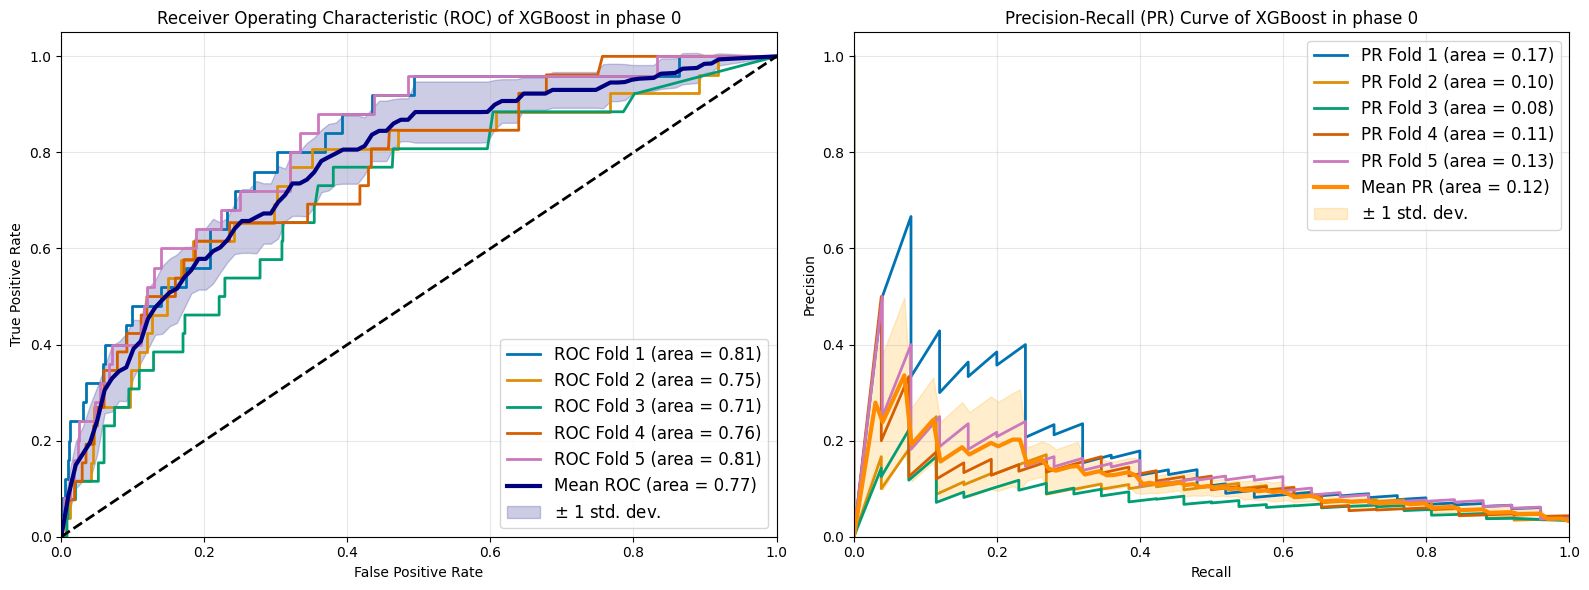

In [37]:
outerPR, outerROC = trainModel(model, paramGrid, Xpre , phase=0, type='XGBoost')

In [38]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 11.8354 
 standard deviation: 3.3448 
 standard error of mean: 1.4959
Nested CV ROC: 
 mean: 76.6991 
 standard deviation: 4.0423 
 standard error of mean: 1.8078


#### XGBoost - phase 1

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 50, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 22.20%
Holdout Set ROC AUC: 77.37%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 10.54%
Holdout Set ROC AUC: 80.56%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 11.61%
Holdout Set ROC AUC: 77.71%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 14.44%
Holdout Set ROC AUC: 78.03%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 

<Figure size 1600x600 with 0 Axes>

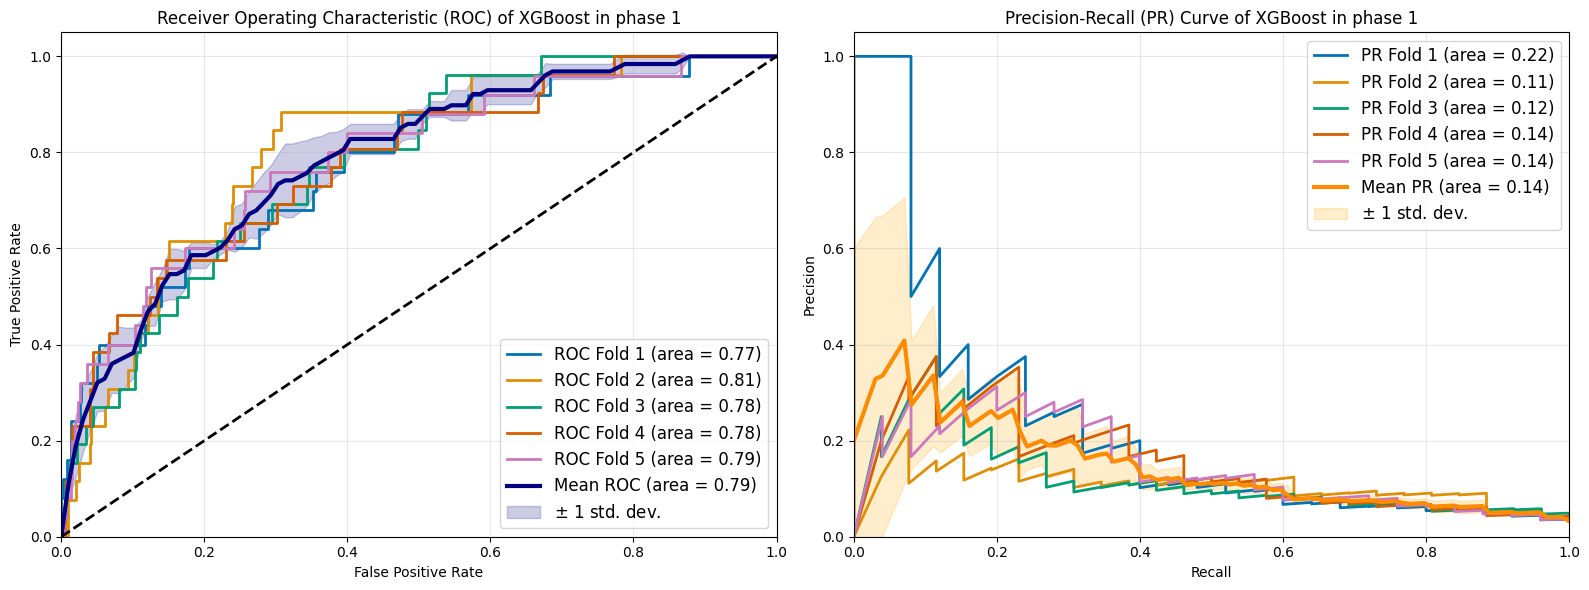

In [39]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase1 , phase=1, type='XGBoost')

In [40]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 14.5704 
 standard deviation: 4.0860 
 standard error of mean: 1.8273
Nested CV ROC: 
 mean: 78.4954 
 standard deviation: 1.1379 
 standard error of mean: 0.5089


#### XGBoost - phase 2

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 19.03%
Holdout Set ROC AUC: 77.92%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 11.05%
Holdout Set ROC AUC: 78.47%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 13.87%
Holdout Set ROC AUC: 82.91%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 17.50%
Holdout Set ROC AUC: 78.59%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate':

<Figure size 1600x600 with 0 Axes>

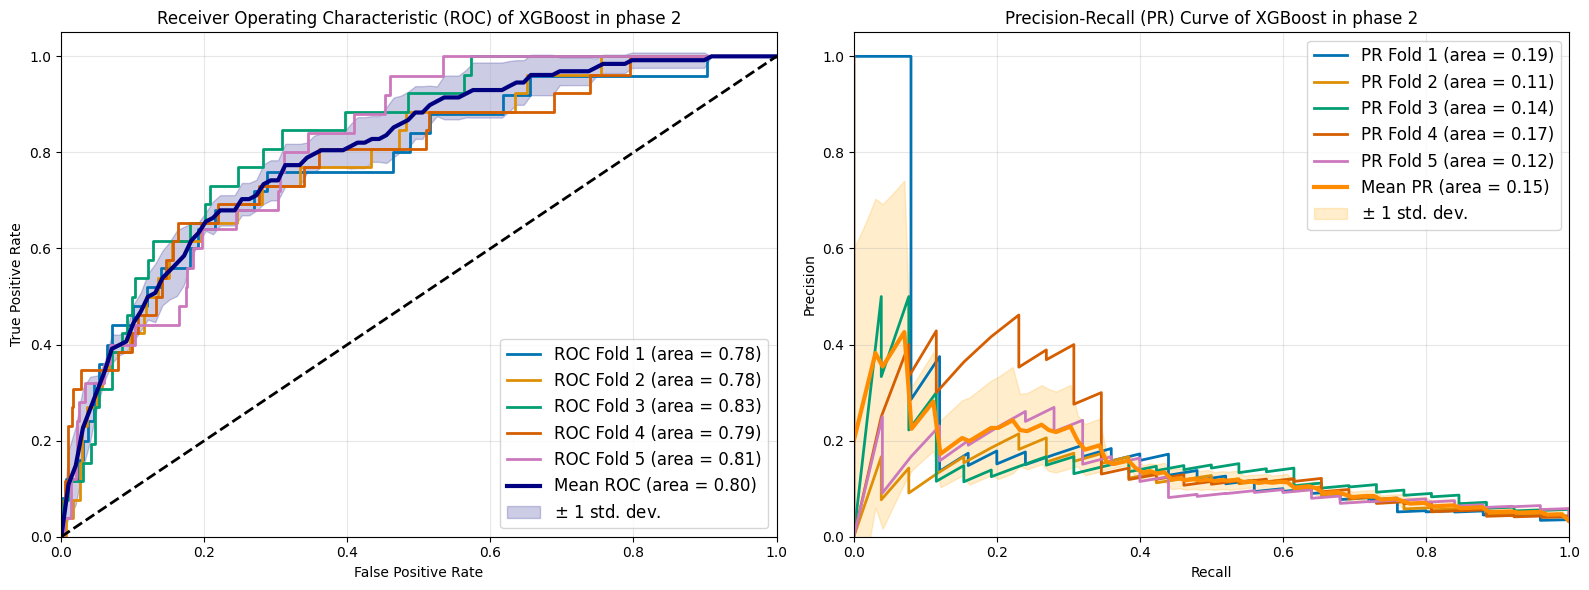

In [41]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase2 , phase=2, type='XGBoost')

In [42]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 14.7588 
 standard deviation: 3.0369 
 standard error of mean: 1.3582
Nested CV ROC: 
 mean: 79.8606 
 standard deviation: 1.9538 
 standard error of mean: 0.8738


#### XGBoost - phase 3

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 31.37%
Holdout Set ROC AUC: 83.43%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 19.07%
Holdout Set ROC AUC: 83.50%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 19.58%
Holdout Set ROC AUC: 86.55%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 29.78%
Holdout Set ROC AUC: 85.41%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate':

<Figure size 1600x600 with 0 Axes>

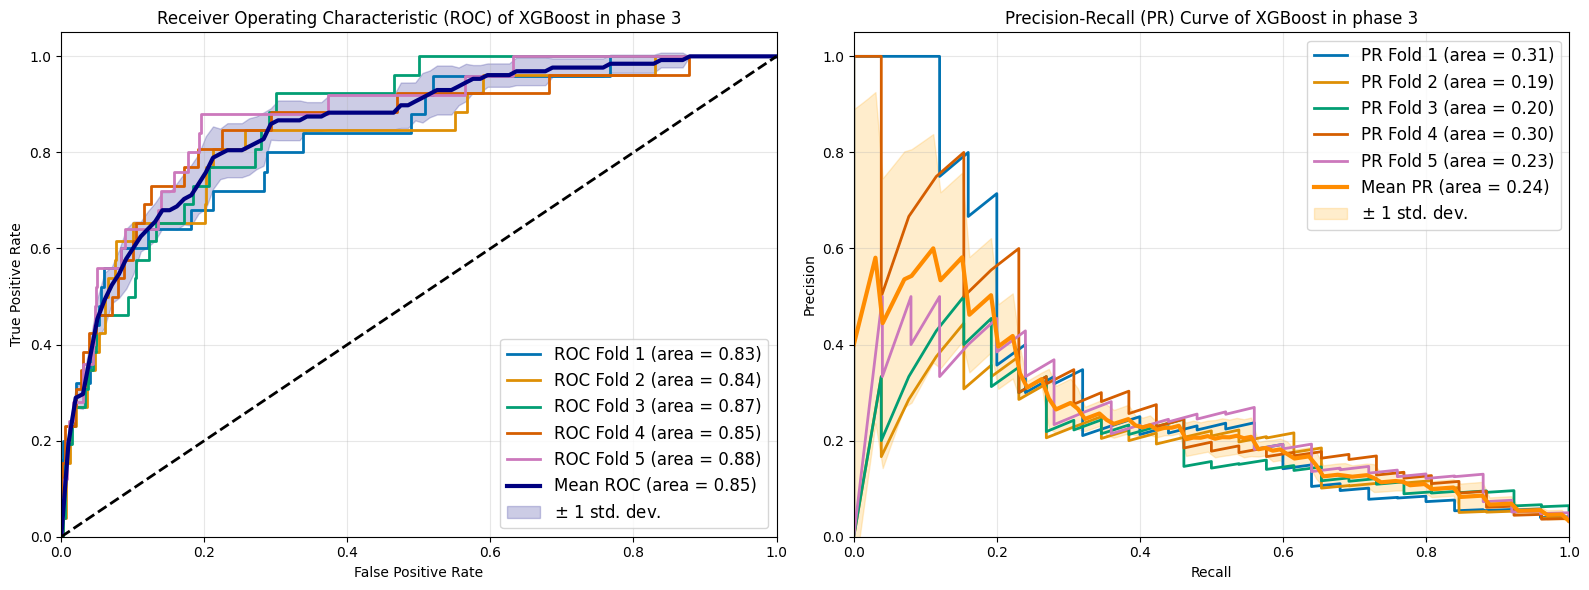

In [43]:
outerPR, outerROC = trainModel(model, paramGrid, Xphase3 , phase=3, type='XGBoost')

In [44]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 24.5608 
 standard deviation: 5.1178 
 standard error of mean: 2.2888
Nested CV ROC: 
 mean: 85.3096 
 standard deviation: 1.6666 
 standard error of mean: 0.7453


In [45]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_XGB_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_XGB_death.fit(Xtrain, yTrain)

    bestModel = grid_search_XGB_death.best_estimator_



    results_XGB_death = grid_search_XGB_death.cv_results_
    best_model_XGB_death = grid_search_XGB_death.best_estimator_
    best_params_XGB_death = grid_search_XGB_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_XGB_death = best_model_XGB_death.predict_proba(Xtest)[:,1]

    fpr, tpr, _ = roc_curve(yTest, y_pred_XGB_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_XGB_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2-foldCount/10, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    # Calculate metrics
    holdout_pr_XGB_death = pr_auc * 100
    holdout_auc_XGB_death = roc_auc_score(yTest, y_pred_XGB_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_XGB_death)
    outerROC.append(holdout_auc_XGB_death)

    # Print the summary
    print(f"Best parameters: {best_params_XGB_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_XGB_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_XGB_death:.2f}%")

    


    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_XGB_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_XGB_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_XGB_death.best_estimator_\n\n\n\n    results_XGB_death = grid_search_XGB_death.cv_results_\n    best_model_XGB_death = grid_search_XGB_death.best_estimator_\n    best_params_XGB_death = grid_search_XGB_death.best_params_\n\n    # Evaluate the model on the holdout set\n    y_pr